In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv("1.csv")
df2=pd.read_csv("2.csv")
df3=pd.read_csv("3.csv")
df4=pd.read_csv("4.csv")
df5=pd.read_csv("5.csv")
df6=pd.read_csv("6.csv")
df7=pd.read_csv("7.csv")
df8=pd.read_csv("8.csv")

In [3]:
combined_df=pd.concat([df1,df2,df3,df4,df5,df6,df7,df8],ignore_index=True)
combined_df.shape

(2830743, 79)

In [4]:
combined_df.to_csv("dataset.csv",index=False)
print("Dataset saved successfully as dataset.csv")

Dataset saved successfully as dataset.csv


In [5]:
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.metrics import *
from xgboost import XGBClassifier
#!pip install shap
import shap

C:\Users\monis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df=pd.read_csv(r"dataset.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.info

<bound method DataFrame.info of           Destination Port   Flow Duration   Total Fwd Packets  \
0                    54865               3                   2   
1                    55054             109                   1   
2                    55055              52                   1   
3                    46236              34                   1   
4                    54863               3                   2   
...                    ...             ...                 ...   
2830738                 53           32215                   4   
2830739                 53             324                   2   
2830740              58030              82                   2   
2830741                 53         1048635                   6   
2830742                 53           94939                   4   

          Total Backward Packets  Total Length of Fwd Packets  \
0                              0                           12   
1                              1             

In [8]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [9]:
df.columns = df.columns.str.strip()

In [10]:

df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Missing values before:", df.isnull().sum().sum())
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

Missing values before: 5734
Shape after cleaning: (2827876, 79)


In [11]:
df['Label'].value_counts()

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [12]:
le=LabelEncoder()
df['Label']=le.fit_transform(df['Label'])

In [13]:
x=df.drop('Label',axis=1)
y=df['Label']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.3,
                                               random_state=42,
                                              stratify=y)


In [15]:
x_train.shape

(1979513, 78)

In [16]:
x_test.shape

(848363, 78)

In [17]:
#baseline model without handling imbalance
xg_model=XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),#predicts probabilities becuase of multiclass classification
    eval_metric='mlogloss',
    tree_method='hist'
)
xg_model.fit(x_train,y_train)
y_pred=xg_model.predict(x_test)

print("Accuracy",accuracy_score(y_test,y_pred))
print("F1 Score: ",f1_score(y_test,y_pred,average='weighted'))

Accuracy 0.9989627081803426
F1 Score:  0.9989329456429715


In [18]:
y_pred_test=xg_model.predict(x_test)
test_acc=accuracy_score(y_test, y_pred_test)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.9989627081803426


In [19]:
print(confusion_matrix(y_test, y_pred))

[[680962     40      3      0     86     11      1      1      0      0
     289      0      3      0      0]
 [   142    445      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     7      0  38401      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     2      0      0   3079      4      3      0      0      0      0
       0      0      0      0      0]
 [    23      0      0      8  69003      0      0      0      0      0
       2      0      1      0      0]
 [     4      0      0      1      0   1636      6      0      0      0
       0      0      1      0      2]
 [     2      0      0      0      1      2   1734      0      0      0
       0      0      0      0      0]
 [     0      0      0      0      0      0      0   2379      0      0
       0      0      1      0      0]
 [     0      0      0      0      0      0      0      0      3      0
       0      0      0      0      0]
 [     6  

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    681396
           1       0.92      0.76      0.83       587
           2       1.00      1.00      1.00     38408
           3       1.00      1.00      1.00      3088
           4       1.00      1.00      1.00     69037
           5       0.99      0.99      0.99      1650
           6       1.00      1.00      1.00      1739
           7       1.00      1.00      1.00      2380
           8       1.00      1.00      1.00         3
           9       1.00      0.45      0.62        11
          10       0.99      1.00      1.00     47641
          11       1.00      1.00      1.00      1769
          12       0.73      0.85      0.79       452
          13       0.67      0.33      0.44         6
          14       0.48      0.30      0.37       196

    accuracy                           1.00    848363
   macro avg       0.92      0.85      0.87    848363
weighted avg       1.00   

In [21]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [22]:
from xgboost import XGBClassifier

xg_model_weighted=XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

xg_model_weighted.fit(
    x_train,
    y_train,
    sample_weight=sample_weights
)
y_pred_weighted=xg_model_weighted.predict(x_test)

In [23]:
print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    681396
           1       0.67      0.99      0.80       587
           2       1.00      1.00      1.00     38408
           3       0.98      1.00      0.99      3088
           4       1.00      1.00      1.00     69037
           5       0.98      0.99      0.99      1650
           6       0.99      0.99      0.99      1739
           7       1.00      1.00      1.00      2380
           8       0.75      1.00      0.86         3
           9       1.00      1.00      1.00        11
          10       0.99      1.00      1.00     47641
          11       1.00      1.00      1.00      1769
          12       0.74      0.79      0.76       452
          13       0.75      0.50      0.60         6
          14       0.45      0.43      0.44       196

    accuracy                           1.00    848363
   macro avg       0.89      0.91      0.89    848363
weighted avg       1.00   

In [24]:
explainer=shap.TreeExplainer(xg_model_weighted)

In [25]:
shap_values=explainer.shap_values(x_test)

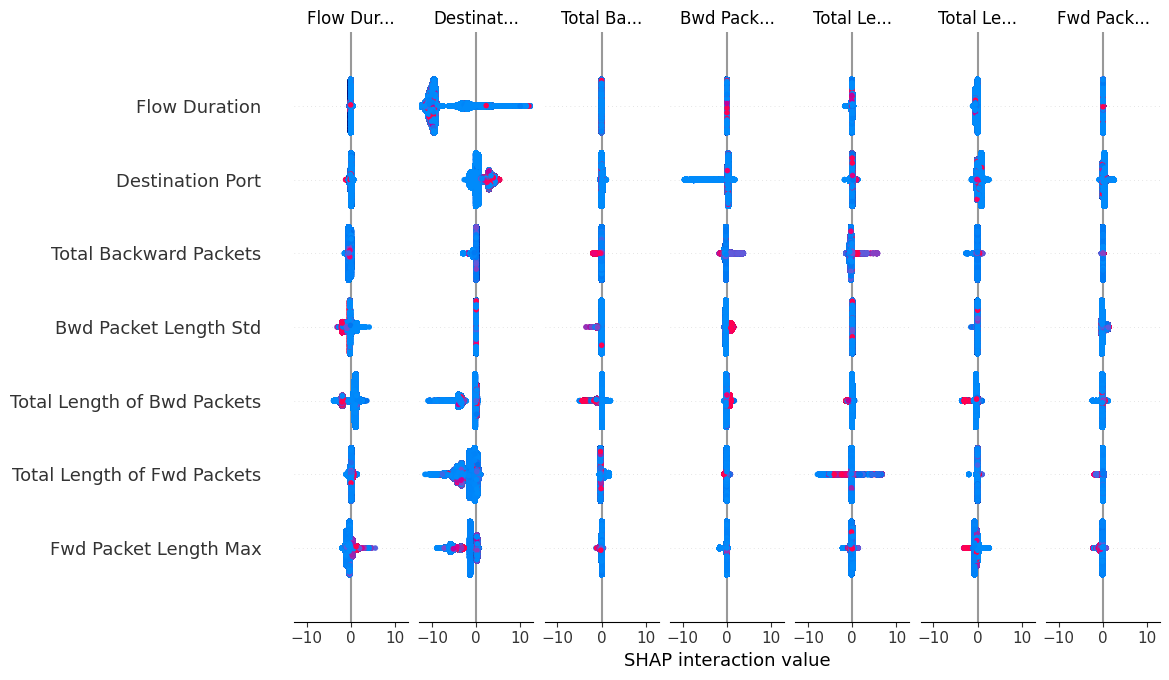

In [26]:
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=x_test.columns
)

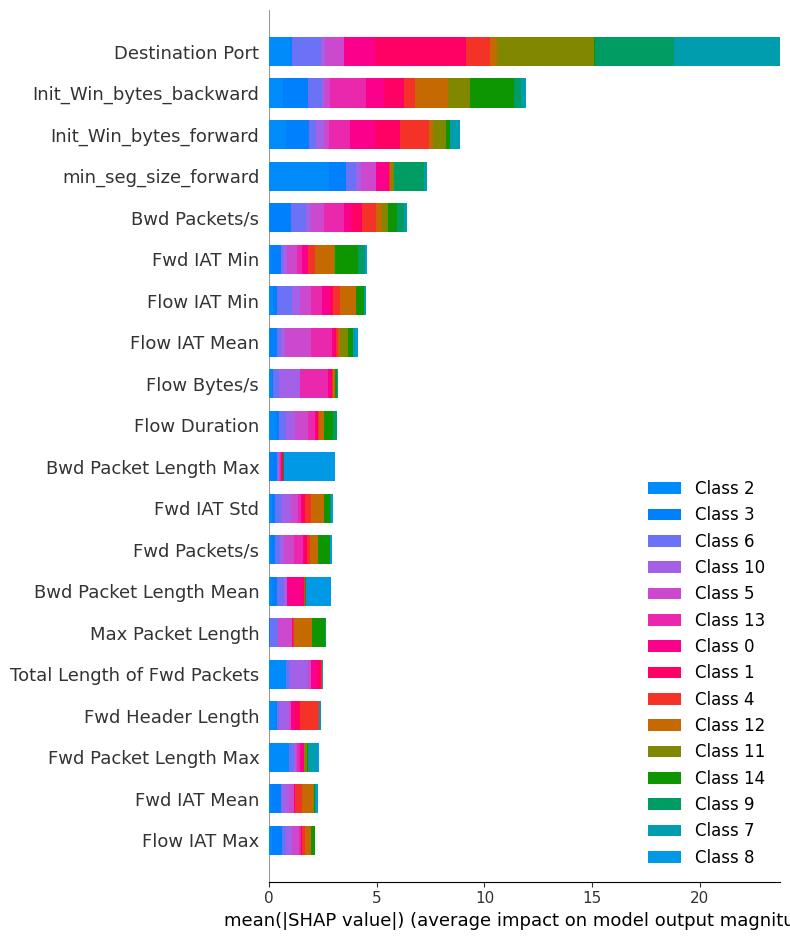

In [27]:
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=x_test.columns,
    plot_type="bar"
)

In [28]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of class 0:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)

print("x_test shape:", x_test.shape)

<class 'numpy.ndarray'>
Shape: (848363, 78, 15)
x_test shape: (848363, 78)


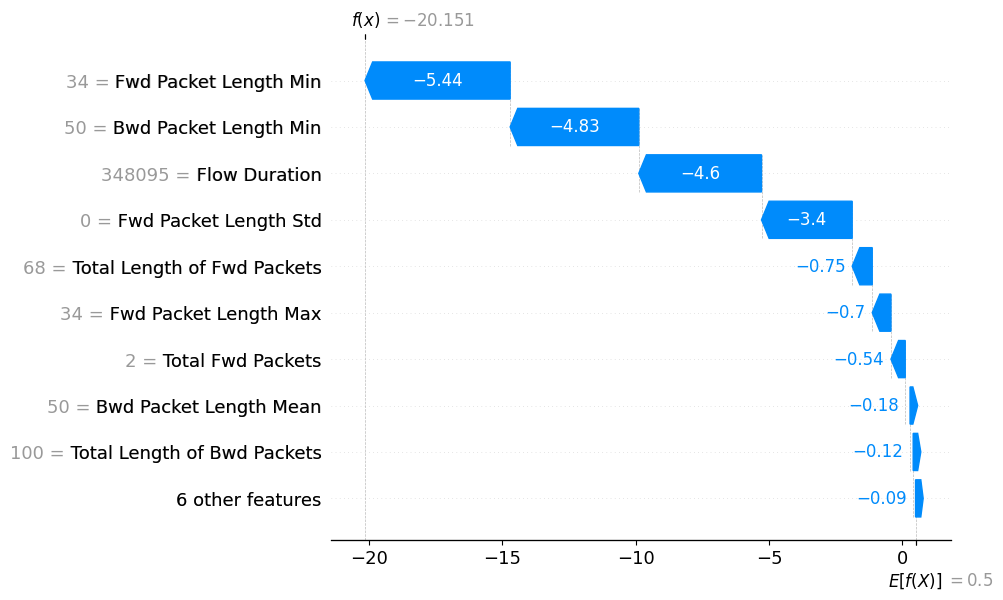

In [29]:
sample_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0][sample_idx],
        base_values=explainer.expected_value[0],
        data=x_test.iloc[sample_idx],
        feature_names=x_test.columns
    )
)

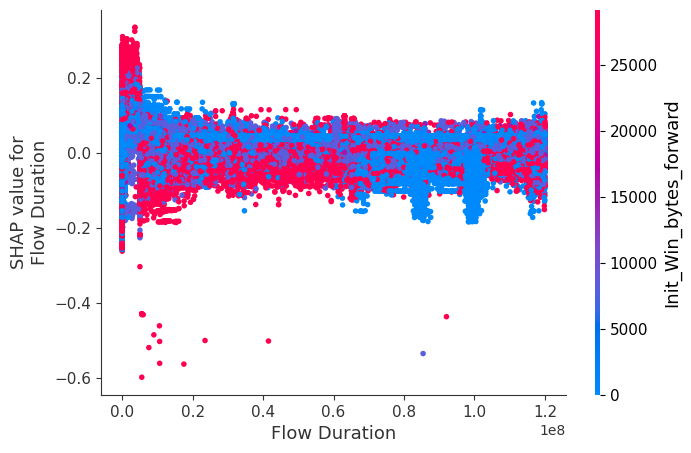

In [30]:
class_idx = 0

shap.dependence_plot(
    "Flow Duration",
    shap_values[:, :, class_idx],
    x_test
)